In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib

# Load processed data
model_df = pd.read_csv("../data/processed/model_data.csv")

model_df.head()

,StockCode,Month,UnitsSold,AvgPrice,Revenue,lag_1_units,rolling_3_units,price_change_pct,month_num,year
0,15036,2011-02-01,2172,0.740476,1449.00,912.0,1072.000000,0.012040,2,2011
1,15036,2011-03-01,2912,0.735000,1986.00,2172.0,1998.666667,-0.007395,3,2011
2,15036,2011-04-01,1900,0.813667,1431.68,2912.0,2328.000000,0.107029,4,2011
3,15036,2011-05-01,3888,0.820000,2921.04,1900.0,2900.000000,0.007784,5,2011
4,15036,2011-06-01,3096,0.819800,2323.08,3888.0,2961.333333,-0.000244,6,2011


In [2]:
# Load model
model = joblib.load("../models/demand_model.pkl")

In [3]:
model_df = pd.get_dummies(model_df, columns=['StockCode'])

In [4]:
# Select features and target
features = [col for col in model_df.columns if col not in ['UnitsSold', 'Month']]

target = 'UnitsSold'

In [5]:
model_df.head()

,Month,UnitsSold,AvgPrice,Revenue,lag_1_units,rolling_3_units,price_change_pct,month_num,year,StockCode_15036,...,StockCode_84755,StockCode_84879,StockCode_84946,StockCode_84978,StockCode_84991,StockCode_84992,StockCode_85099B,StockCode_85099C,StockCode_85099F,StockCode_85123A
0,2011-02-01,2172,0.740476,1449.00,912.0,1072.000000,0.012040,2,2011,1,...,0,0,0,0,0,0,0,0,0,0
1,2011-03-01,2912,0.735000,1986.00,2172.0,1998.666667,-0.007395,3,2011,1,...,0,0,0,0,0,0,0,0,0,0
2,2011-04-01,1900,0.813667,1431.68,2912.0,2328.000000,0.107029,4,2011,1,...,0,0,0,0,0,0,0,0,0,0
3,2011-05-01,3888,0.820000,2921.04,1900.0,2900.000000,0.007784,5,2011,1,...,0,0,0,0,0,0,0,0,0,0
4,2011-06-01,3096,0.819800,2323.08,3888.0,2961.333333,-0.000244,6,2011,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Select a product
product_id = model_df['StockCode_84755'].iloc[0]

product_data = model_df[model_df['StockCode_84755'] == product_id].copy()

In [7]:
# Take latest row
latest = product_data.iloc[-1:].copy()

In [8]:
# Simulate price range
price_range = np.linspace(
    latest['AvgPrice'].values[0] * 0.8,
    latest['AvgPrice'].values[0] * 1.2,
    20
)

In [9]:
# Predict demand for each price
results = []

base_price = latest['AvgPrice'].values[0]

for price in price_range:
    temp = latest.copy()
    temp['AvgPrice'] = price
    temp['price_change_pct'] = (price - base_price) / base_price

    predicted_units = model.predict(temp[features])[0]

    revenue = price * predicted_units

    results.append({
        'price': price,
        'predicted_units': predicted_units,
        'revenue': revenue
    })

sim_df = pd.DataFrame(results)

In [10]:
# Find optimal price
best_row = sim_df.loc[sim_df['revenue'].idxmax()]
print(best_row)

price                 2.529345
predicted_units    1651.280000
revenue            4176.657187
Name: 3, dtype: float64


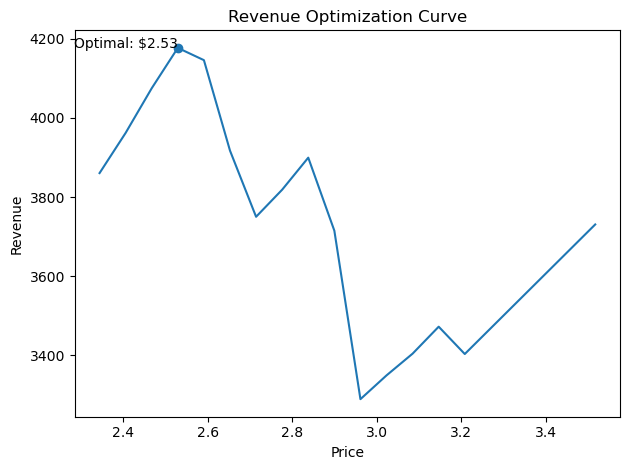

In [11]:
# Visualizations
plt.plot(sim_df['price'], sim_df['revenue'])

plt.scatter(best_row['price'], best_row['revenue'])
plt.text(best_row['price'], best_row['revenue'],
         f"Optimal: ${best_row['price']:.2f}",
         ha='right')

plt.xlabel('Price')
plt.ylabel('Revenue')
plt.title('Revenue Optimization Curve')

plt.tight_layout()
plt.savefig("../images/revenue_optimization_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Revenue lift
baseline_price = base_price
baseline_units = latest['UnitsSold'].values[0]
baseline_revenue = baseline_price * baseline_units

optimized_revenue = best_row['revenue']

lift = (optimized_revenue - baseline_revenue) / baseline_revenue

print(f"Revenue Lift: {lift:.2%}")

Revenue Lift: 77.72%
